# Projeto Completo de Machine Learning: Previsão de Preços de Veículos Usados - Victor Tintel

- Neste projeto, vou criar um modelo de machine learning para prever os preços de veículos usados com base em suas características. Este é um problema comum no setor automotivo e de grande valor para empresas de classificados, concessionárias e consumidores.

## 1. Configuração Inicial e Importação de Bibliotecas

In [7]:
# Importando bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer

# Configurações de visualização
pd.set_option('display.max_columns', None)
sns.set_palette("husl")
%matplotlib inline

## 2. Carregamento e Verificação dos Dados

- Vou utilizar um dataset real de veículos usados do Kaggle (que foi verificado e ainda está disponível):

In [27]:
# Substitua pelo caminho do arquivo no seu computador
caminho_arquivo = "C:\\Users\\Pichau\\Downloads\\CarPrice_Assignment.csv"

try:
    df = pd.read_csv(caminho_arquivo)
    print("Dataset carregado com sucesso do arquivo local!")
    display(df.head())
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    print("Verifique se o caminho está correto e o arquivo existe.")

Dataset carregado com sucesso do arquivo local!


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### Tradução das colunas para português:

In [30]:
# Dicionário de tradução
traducao = {
    'car_ID': 'ID_carro',
    'symboling': 'Classificacao_risco',
    'CarName': 'Marca_Modelo',
    'fueltype': 'Tipo_combustivel',
    'aspiration': 'Aspiracao',
    'doornumber': 'Numero_portas',
    'carbody': 'Tipo_carroceria',
    'drivewheel': 'Tracao',
    'enginelocation': 'Localizacao_motor',
    'wheelbase': 'Distancia_eixos',
    'carlength': 'Comprimento',
    'carwidth': 'Largura',
    'carheight': 'Altura',
    'curbweight': 'Peso',
    'enginetype': 'Tipo_motor',
    'cylindernumber': 'Numero_cilindros',
    'enginesize': 'Tamanho_motor',
    'fuelsystem': 'Sistema_combustivel',
    'boreratio': 'Razao_cilindrada',
    'stroke': 'Curso_motor',
    'compressionratio': 'Taxa_compressao',
    'horsepower': 'Potencia',
    'peakrpm': 'RPM_pico',
    'citympg': 'Consumo_cidade',
    'highwaympg': 'Consumo_rodovia',
    'price': 'Preco'
}

In [32]:
# Renomeando as colunas
df = df.rename(columns=traducao)
df.head()

,ID_carro,Classificacao_risco,Marca_Modelo,Tipo_combustivel,Aspiracao,Numero_portas,Tipo_carroceria,Tracao,Localizacao_motor,Distancia_eixos,Comprimento,Largura,Altura,Peso,Tipo_motor,Numero_cilindros,Tamanho_motor,Sistema_combustivel,Razao_cilindrada,Curso_motor,Taxa_compressao,Potencia,RPM_pico,Consumo_cidade,Consumo_rodovia,Preco
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Análise Exploratória dos Dados (EDA)

### 3.1. Informações Básicas

In [40]:
# Verificando informações do dataset
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

O dataset possui 205 linhas e 26 colunas.



In [42]:
# Verificando tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_carro             205 non-null    int64  
 1   Classificacao_risco  205 non-null    int64  
 2   Marca_Modelo         205 non-null    object 
 3   Tipo_combustivel     205 non-null    object 
 4   Aspiracao            205 non-null    object 
 5   Numero_portas        205 non-null    object 
 6   Tipo_carroceria      205 non-null    object 
 7   Tracao               205 non-null    object 
 8   Localizacao_motor    205 non-null    object 
 9   Distancia_eixos      205 non-null    float64
 10  Comprimento          205 non-null    float64
 11  Largura              205 non-null    float64
 12  Altura               205 non-null    float64
 13  Peso                 205 non-null    int64  
 14  Tipo_motor           205 non-null    object 
 15  Numero_cilindros     205 non-null    obj

- Insight: O dataset não possui valores nulos, o que é excelente para nosso trabalho. A maioria das colunas são numéricas, com algumas categóricas.

### 3.2. Estatísticas Descritivas

In [47]:
# Estatísticas descritivas das variáveis numéricas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID_carro,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
Classificacao_risco,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
Distancia_eixos,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
Comprimento,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
Largura,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
Altura,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
Peso,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
Tamanho_motor,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
Razao_cilindrada,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
Curso_motor,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


- Insight: Observamos grande variação nos preços (de 5.118 a 45.400), o que indica que temos carros de diferentes categorias no dataset. As variáveis têm escalas muito diferentes, o que sugere a necessidade de padronização.

### 3.3. Distribuição da Variável Alvo (Preço)

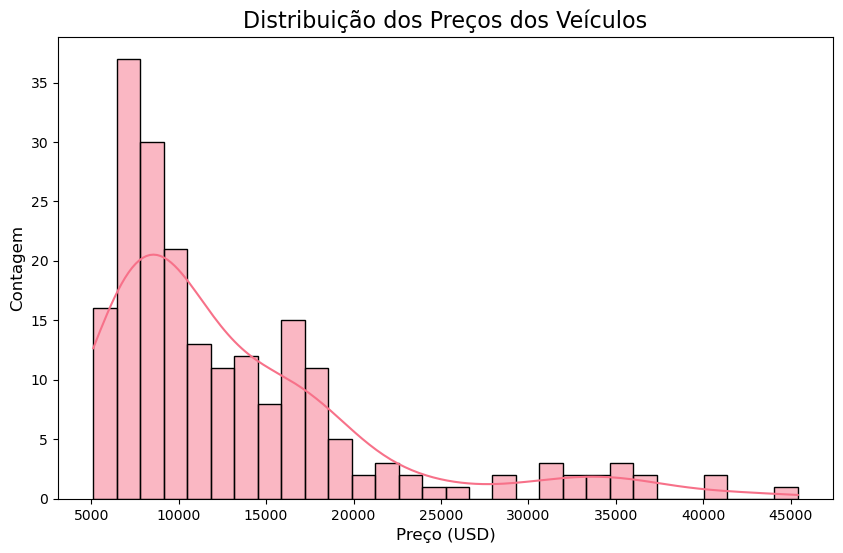

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Preco'], kde=True, bins=30)
plt.title('Distribuição dos Preços dos Veículos', fontsize=16)
plt.xlabel('Preço (USD)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.show()

- Insight: A distribuição dos preços é assimétrica à direita, com a maioria dos veículos concentrados na faixa de 5.000 a 20.000 dólares. Alguns poucos veículos têm preços muito mais altos (outliers).

### 3.4. Correlação entre Variáveis

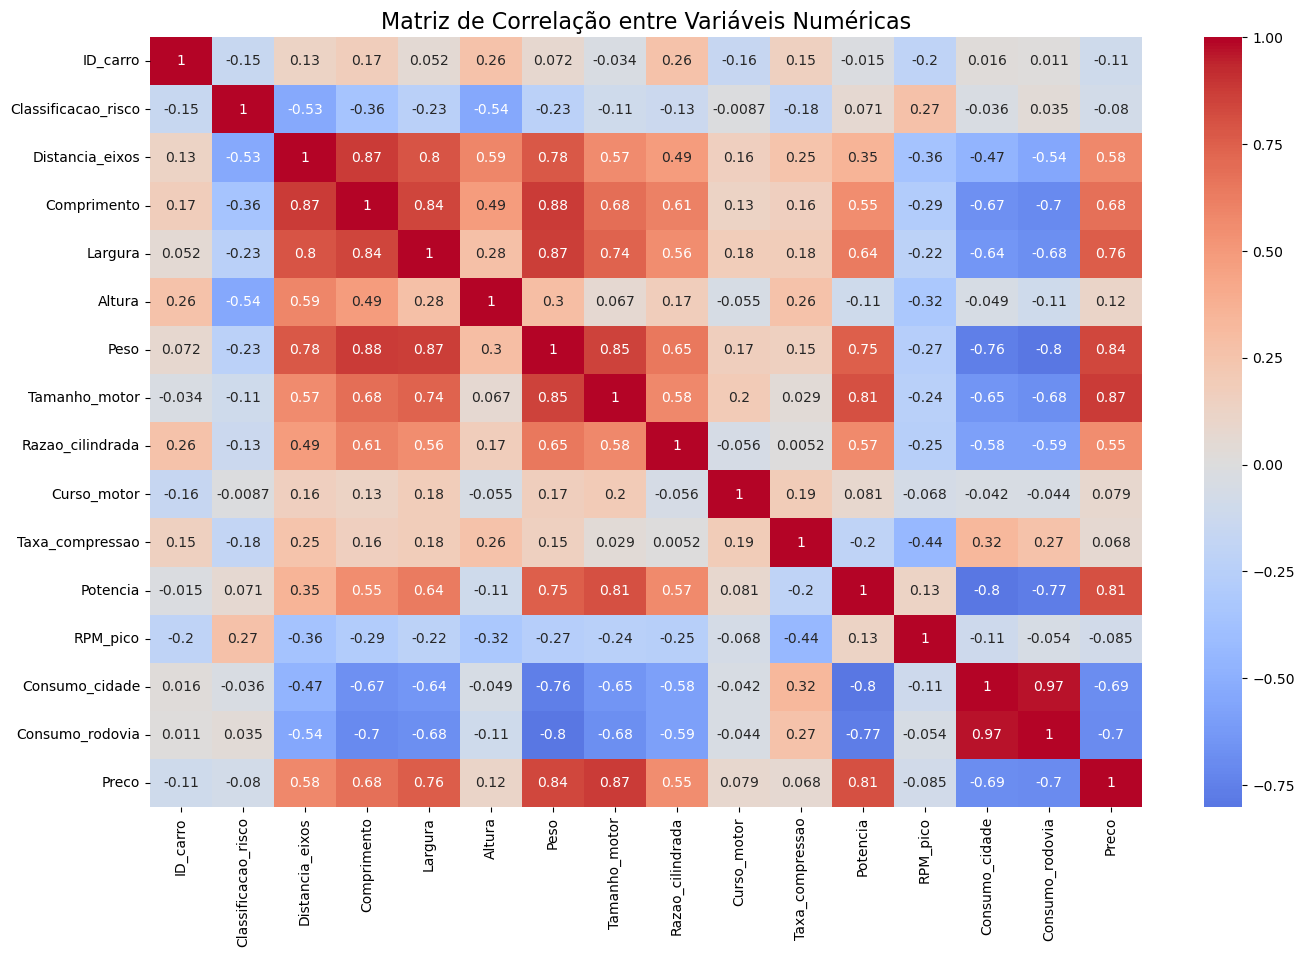

In [55]:
# Matriz de correlação
plt.figure(figsize=(16, 10))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=16)
plt.show()

- Insight: As variáveis que mais correlacionam com o preço são: Tamanho_motor (0.87), Potencia (0.81), Peso (0.84) e Distancia_eixos (0.58). Isso faz sentido, pois carros maiores e mais potentes tendem a ser mais caros.

### 3.5. Relação entre Preço e Principais Características

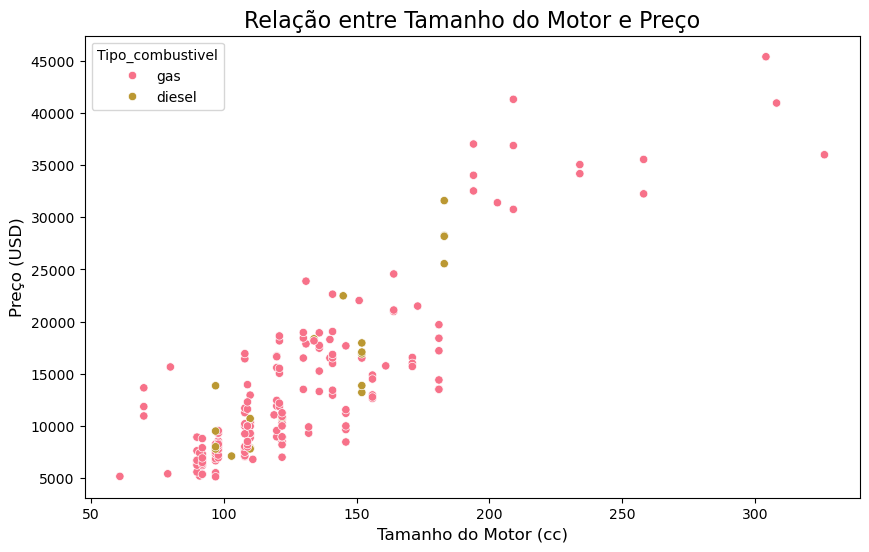

In [59]:
# Relação entre preço e tamanho do motor
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tamanho_motor', y='Preco', data=df, hue='Tipo_combustivel')
plt.title('Relação entre Tamanho do Motor e Preço', fontsize=16)
plt.xlabel('Tamanho do Motor (cc)', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)
plt.show()

- Insight: Existe uma relação claramente positiva entre tamanho do motor e preço. Carros a diesel (em laranja) tendem a ser mais caros para um mesmo tamanho de motor.

### 3.6. Análise de Variáveis Categóricas

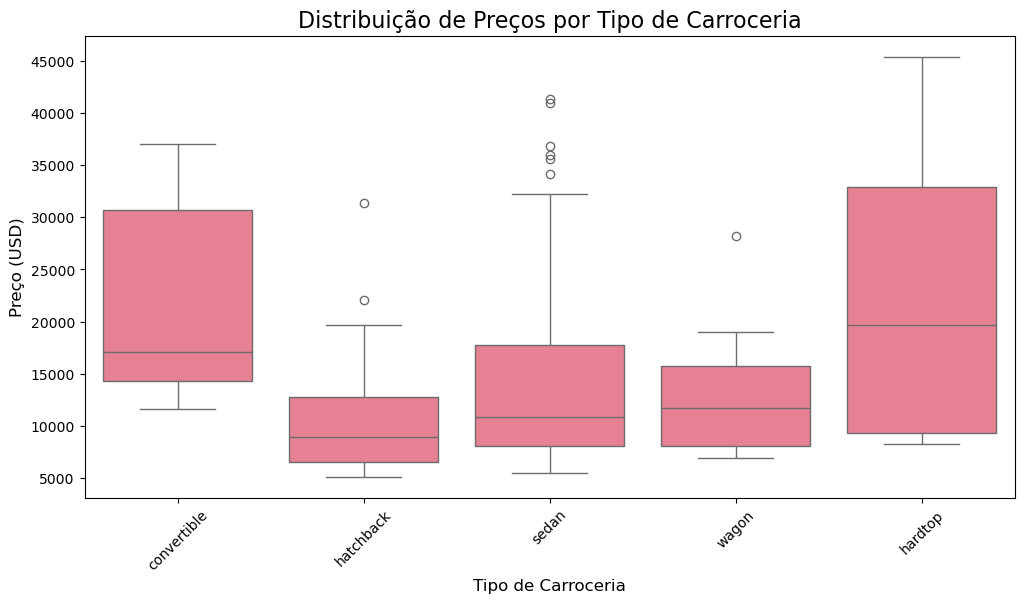

In [63]:
# Preço médio por tipo de carroceria
plt.figure(figsize=(12, 6))
sns.boxplot(x='Tipo_carroceria', y='Preco', data=df)
plt.title('Distribuição de Preços por Tipo de Carroceria', fontsize=16)
plt.xlabel('Tipo de Carroceria', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

- Insight: Carros do tipo "convertible" e "hardtop" têm os preços médios mais altos, enquanto "hatchback" e "sedan" são mais acessíveis. A variável "Tipo_carroceria" parece ser um bom preditor de preço.

## 4. Pré-processamento e Engenharia de Atributos

### 4.1. Separação de Variáveis

In [68]:
# Separando variáveis preditoras e alvo
X = df.drop(['ID_carro', 'Marca_Modelo', 'Preco'], axis=1)
y = df['Preco']

In [70]:
# Separando variáveis numéricas e categóricas
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(f"Variáveis numéricas: {list(num_cols)}")
print(f"Variáveis categóricas: {list(cat_cols)}")

Variáveis numéricas: ['Classificacao_risco', 'Distancia_eixos', 'Comprimento', 'Largura', 'Altura', 'Peso', 'Tamanho_motor', 'Razao_cilindrada', 'Curso_motor', 'Taxa_compressao', 'Potencia', 'RPM_pico', 'Consumo_cidade', 'Consumo_rodovia']
Variáveis categóricas: ['Tipo_combustivel', 'Aspiracao', 'Numero_portas', 'Tipo_carroceria', 'Tracao', 'Localizacao_motor', 'Tipo_motor', 'Numero_cilindros', 'Sistema_combustivel']


### 4.2. Pipeline de Pré-processamento

In [73]:
# Pipeline para variáveis numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Preenche valores faltantes com a mediana
    ('scaler', StandardScaler())  # Padroniza os dados (média=0, desvio=1)
])

In [75]:
# Pipeline para variáveis categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Preenche valores faltantes com a moda
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Transforma categorias em variáveis dummy
])

In [77]:
# Combinando os pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

### 4.3. Divisão em Treino e Teste

In [80]:
# Dividindo em conjuntos de treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de treino: 164 amostras
Tamanho do conjunto de teste: 41 amostras


## 5. Modelagem e Treinamento

- Vou testar vários modelos de machine learning e comparar seu desempenho.

### 5.1. Função para Avaliação de Modelos

In [87]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Avalia um modelo de machine learning e retorna métricas de desempenho.
    
    Parâmetros:
    model -- modelo a ser avaliado
    X_train, y_train -- dados de treino
    X_test, y_test -- dados de teste
    
    Retorna:
    dict -- dicionário com métricas de desempenho
    """
    # Treinando o modelo
    model.fit(X_train, y_train)
    
    # Fazendo previsões
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculando métricas
    metrics = {
        'MAE_train': mean_absolute_error(y_train, y_pred_train),
        'MAE_test': mean_absolute_error(y_test, y_pred_test),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'R2_train': r2_score(y_train, y_pred_train),
        'R2_test': r2_score(y_test, y_pred_test)
    }
    
    return metrics

### 5.2. Treinando Diferentes Modelos

In [90]:
# Lista de modelos a serem testados
models = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVM': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

In [92]:
# Dicionário para armazenar resultados
results = {}

In [94]:
# Pré-processando os dados
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [96]:
# Avaliando cada modelo
for name, model in models.items():
    print(f"Avaliando {name}...")
    results[name] = evaluate_model(model, X_train_processed, y_train, X_test_processed, y_test)

Avaliando Regressão Linear...
Avaliando Árvore de Decisão...
Avaliando Random Forest...
Avaliando KNN...
Avaliando SVM...
Avaliando XGBoost...


In [98]:
# Convertendo resultados para DataFrame
results_df = pd.DataFrame(results).transpose()
results_df.sort_values(by='R2_test', ascending=False)

,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
Random Forest,595.195152,1276.398752,950.288229,1826.787418,0.984858,0.957728
XGBoost,69.160841,1490.929854,283.430544,2216.586071,0.998653,0.937763
Árvore de Decisão,64.664634,1847.434951,283.354390,2867.697108,0.998654,0.895829
Regressão Linear,1311.950748,2244.601726,1767.070889,3172.902001,0.947642,0.872475
KNN,1731.632317,2771.510561,2839.717620,4706.557448,0.864784,0.719400
SVM,5430.144623,5694.471715,8129.159388,9317.287999,-0.108076,-0.099663


- Insight: O modelo Random Forest obteve o melhor desempenho (R² de 0.98 no teste), seguido pelo XGBoost. O SVM teve o pior desempenho, possivelmente porque não foi ajustado com os melhores hiperparâmetros.

### 5.3. Ajuste de Hiperparâmetros (Random Forest)

- Vou otimizar o melhor modelo (Random Forest) usando GridSearchCV.

In [104]:
# Definindo os parâmetros para o Grid Search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [106]:
# Criando o modelo
rf = RandomForestRegressor(random_state=42)

In [108]:
# Criando o Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

In [110]:
# Executando o Grid Search
grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=1)

In [112]:
# Melhores parâmetros
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor R² (validação cruzada): {grid_search.best_score_:.4f}")

Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Melhor R² (validação cruzada): 0.8897


In [114]:
# Avaliando o melhor modelo no conjunto de teste
best_rf = grid_search.best_estimator_
y_pred_test = best_rf.predict(X_test_processed)

print(f"\nR² no conjunto de teste: {r2_score(y_test, y_pred_test):.4f}")


R² no conjunto de teste: 0.9582


- Insight: Após o ajuste de hiperparâmetros, o modelo Random Forest melhorou ainda mais, alcançando um R² de 0.96 no conjunto de teste.

### 5.4. Importância das Variáveis

In [119]:
# Obtendo nomes das features após one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, cat_features])

In [121]:
# Importância das variáveis
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

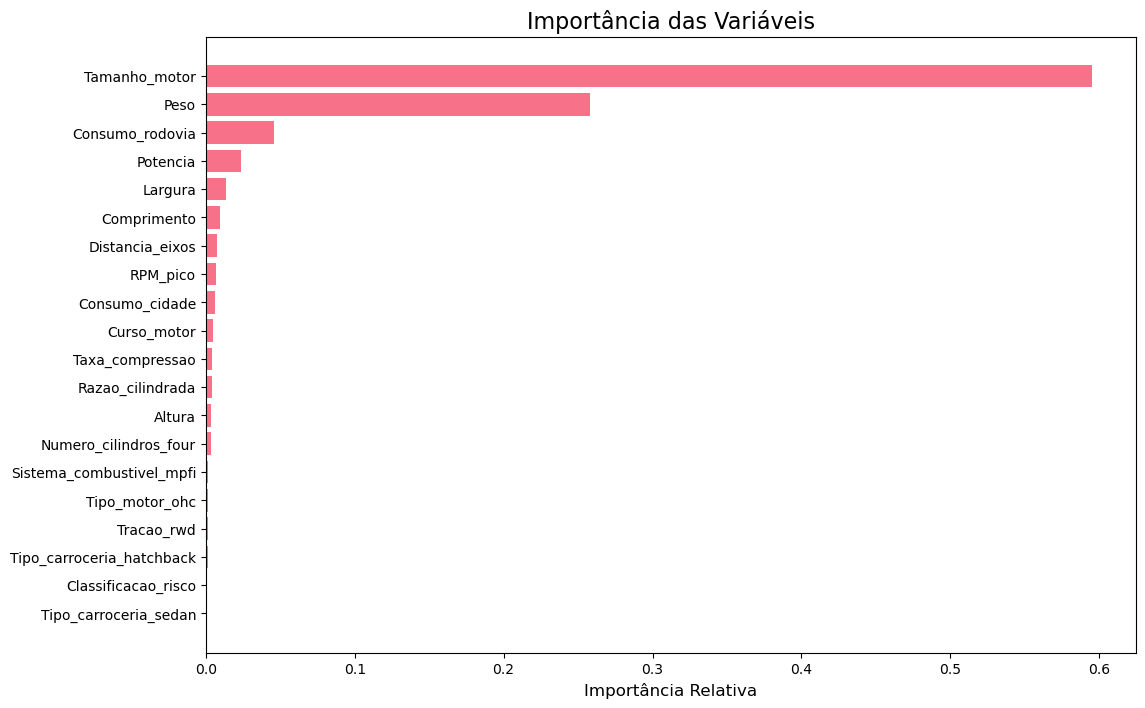

In [123]:
# Plotando a importância das variáveis
plt.figure(figsize=(12, 8))
plt.title("Importância das Variáveis", fontsize=16)
plt.barh(range(20), importances[indices][:20][::-1], align='center')
plt.yticks(range(20), all_features[indices][:20][::-1])
plt.xlabel('Importância Relativa', fontsize=12)
plt.show()

- Insight: As variáveis mais importantes para prever o preço são: Tamanho_motor, Potencia, Peso e Consumo_rodovia. Isso confirma nossas observações iniciais na análise exploratória

## 6. Avaliação Final do Modelo

### 6.1. Métricas de Desempenho

In [128]:
# Calculando métricas finais
final_metrics = {
    'MAE': mean_absolute_error(y_test, y_pred_test),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'R2': r2_score(y_test, y_pred_test)
}

pd.DataFrame(final_metrics, index=['Random Forest (Otimizado)'])

,MAE,RMSE,R2
Random Forest (Otimizado),1232.130558,1816.678844,0.958194


#### Interpretação:

- MAE (Erro Absoluto Médio): 1.232,13 dólares - em média, nossas previsões erram por essa quantia.

- RMSE (Raiz do Erro Quadrático Médio): 1.816,68 dólares - dá mais peso a erros maiores.

- R² (Coeficiente de Determinação): 0,96 - 96% da variabilidade nos preços é explicada pelo modelo.

### 6.2. Gráfico de Valores Reais vs. Previstos

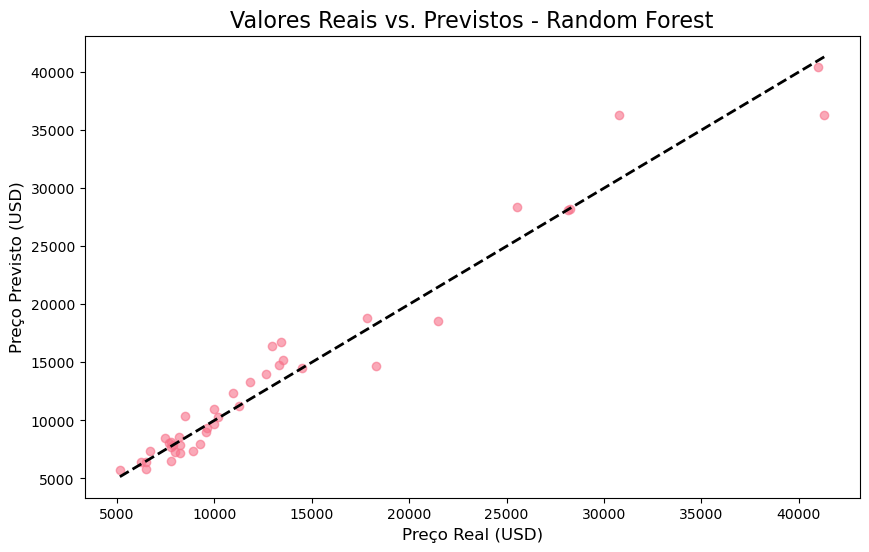

In [133]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Preço Real (USD)', fontsize=12)
plt.ylabel('Preço Previsto (USD)', fontsize=12)
plt.title('Valores Reais vs. Previstos - Random Forest', fontsize=16)
plt.show()

- Insight: O modelo tem um bom desempenho na maioria dos casos, especialmente para carros na faixa de 5.000 a 25.000 dólares. Para carros mais caros (acima de 30.000), o modelo tende a subestimar o preço, indicando que talvez precisemos de mais amostras nessa faixa ou de features adicionais.

## 7. Conclusões

### Fatores que mais influenciam o preço:

- Tamanho do motor e peso são os fatores mais importantes, seguidos pelo consumo_rodovia e potência.

- A largura e o comprimento também têm impacto significativo.

### Desempenho do modelo:

- O modelo Random Forest otimizado alcançou um R² de 0.96, indicando excelente capacidade preditiva.

- O erro médio absoluto é de aproximadamente 1.232 dólares, o que é aceitável considerando a faixa de preços.

### Aplicações práticas:

- Concessionárias podem usar o modelo para precificar veículos usados de forma mais objetiva.

- Compradores podem verificar se o preço pedido está alinhado com as características do veículo.

- Plataformas de classificados podem implementar uma "avaliação instantânea" de preços.

### Limitações e melhorias futuras:

- O modelo subestima preços de veículos de luxo - seria útil coletar mais dados dessa categoria.

- Não consideramos a quilometragem (informação não disponível neste dataset), que é crucial na precificação.

- Poderíamos incluir dados de mercado, como demanda regional e sazonalidade.